<a href="https://colab.research.google.com/github/jpopineda/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 3**

---

# **Previsão de Vida Útil Restante em Motores de Aviação Turbofan: Otimização de Custos e Sustentabilidade na Aviação**:

---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'João Pedro Oliveira Pineda, 10433696' #@param {type:"string"}
Aluno2 = 'Bruno Henrique Ferreira, 10443074' #@param {type:"string"}


# **Introdução**

A manutenção de aeronaves é tradicionalmente regida por cronogramas rígidos baseados em horas de voo ou ciclos (manutenção preventiva). Embora segura, essa abordagem frequentemente resulta na substituição prematura de componentes que ainda possuem vida útil ou em falhas inesperadas que causam o indisponibilidade da aeronave (Aircraft on Ground - AOG) e riscos para a segurança da operação.

Este projeto propõe a transição de um modelo preventivo para um preditivo (baseado em condição) utilizando algoritmos de aprendizado de máquina em dados de séries temporais. Ao modelar a degradação de motores turbofan por meio de sensores de telemetria, o projeto visa calcular o Remaining Useful Life (RUL) dos equipamentos, traduzindo ruído de dados em decisões estratégicas.

A motivação deste trabalho apoia-se em dois pilares principais:

*   Alinhamento aos ODS 9 e 12:
  Em relação ao ODS 9, o projeto promove a modernização da infraestrutura de manutenção aeroviária por meio de inteligência artificial, tornando o setor mais resiliente e inovador.
 Já para o ODS 12, o objetivo é criar um modelo que maximiza o ciclo de vida dos componentes do motor, reduzindo o descarte prematuro de peças de alto custo e mitigando o desperdício de materiais na cadeia de suprimentos.

*   Impacto no Negócio: O projeto terá um olhar sob duas óticas: a manutenção excessiva das aeronaves gera custos desnecessários  e também a manutenção insuficiente gera quebras catastróficas. O modelo se justifica com o objetivo de criar uma predição que reduza os custos de AOG e otimiza o estoque de peças, equilibrando risco e eficiência.

---

## **Objetivos**

Esse projeto será baseado em objetivos gerais e específicos:

### Objetivo Geral

 Desenvolver um modelo preditivo de séries temporais capaz de estimar o RUL de motores turbofan com base em dados de sensores, culminando em um produto analítico de apoio à decisão.

### Objetivos Específicos:

* Aplicar uma metodologia estruturada de dados (como o CRISP-DM) para mapear o problema desde o entendimento do negócio até o deploy analítico;

* Realizar o tratamento e a engenharia de features em séries temporais multivariadas (ruído de sensores de pressão, temperatura, rotação);

* Desenvolver um modelo de Aprendizado de Máquina, baseado nas melhores práticas de estimativa de RUL, que gere predições de vida-útil de motores turbofan de aeronaves com alta confiabilidade.

 ---

## **Descrição da base de dados**

Os dados utilizados neste estudo (ver em "**Referências**") são provenientes do conjunto Commercial Modular Aero-Propulsion System Simulation (CMAPSS), desenvolvido e disponibilizado pelo Centro de Pesquisa Ames da NASA.

## Tipos de dados

  O CMAPSS é um modelo de simulação que imita o comportamento de um motor turbofan de um avião comercial de 90.000 libras de empuxo. Os dados não são extraídos de voos reais, mas sim gerados de forma sintética para modelar a degradação de componentes internos sob diferentes condições de operação até o ponto de falha (run-to-failure), permitindo a obtenção de uma série de dados de telemetria simulados de degradação do equipamento.

## Estrutura

  A base é subdividida em quatro subconjuntos principais (FD001, FD002, FD003 e FD004) introduzindo diferentes condições operacionais (como altitude e velocidade Mach) e múltiplos modos de falha (degradação do compressor de alta pressão e/ou degradação do fan).


## Variáveis

Cada registro na base de dados representa um ciclo de voo completo e é composto por 26 colunas estruturadas da seguinte forma:

Identificadores (2 variáveis): ID do motor e o número do ciclo atual (tempo).

Condições Operacionais (3 variáveis): Ajustes de altitude, número de Mach e ângulo do acelerador (TRA).

Telemetria de Sensores (21 variáveis): Leituras contínuas de sensores termodinâmicos, incluindo temperatura na saída do compressor de baixa pressão (LPC), pressão estática na saída do compressor de alta pressão (HPC), velocidade física do core, margem de estol, entre outros.



# **Referencial Teórico**

A previsão de Vida Útil Restante (Remaining Useful Life - RUL) é um tema abordado em diversas discussões acadêmicas, principalmente em setores que demandam extrema confiabilidade de processos e equipamentos, como Medicina e Aeroespacial.

Para casos de motores turbofan, esse trabalho é um componente crítico do conceito de Prognostics and Health Management (PHM), o qual é focado em estimar o tempo operacional restante e saúde de um sistema antes que o mesmo falhe, baseando-se em dados históricos e sensorização.

De acordo com o modelo base utilizado para criação do *dataset* CMAPPS (Damage Propagation Modeling for Aircraft
Engine Run-to-Failure Simulation), Um motor turbofan de grande porte é composto por componentes principais que incluem o Fan, compressores de baixa e alta pressão (LPC e HPC), câmara de combustão, turbinas de alta e baixa pressão (HPT e LPT) e bocal de exaustão
. O funcionamento baseia-se no ciclo termodinâmico onde o ar é comprimido, misturado ao combustível para combustão e expandido através das turbinas para gerar empuxo e acionar os compressores
. A degradação desses componentes rotativos afeta diretamente a eficiência térmica e a capacidade de fluxo do sistema.

**Figura 1**

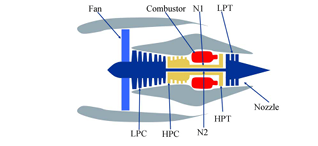

De maneira simplificada, como demonstrado por Samaikya (2024), a Vida Útil Restante (RUL) de um motor aeronáutico corresponde ao tempo em que ele pode operar de forma segura e eficiente antes de exigir reparos ou substituição. O autor destaca que o uso de modelos avançados para prever esse período com precisão viabiliza manutenções preventivas no momento ideal, o que mitiga o risco de falhas imprevistas e reduz os custos de operação.

**Figura 2**

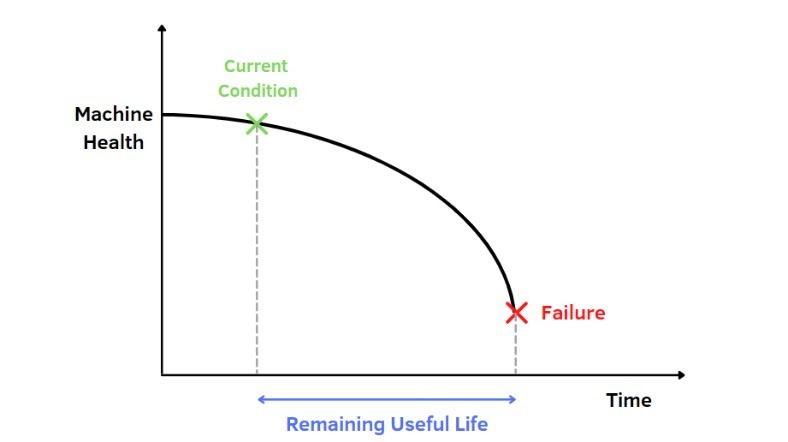

O simulador C-MAPSS (Commercial Modular Aero-Propulsion System Simulation), desenvolvido pela NASA em ambiente Matlab/Simulink, modela um motor de classe de 90.000 lb de empuxo sob diversas condições operacionais de altitude, velocidade Mach e temperatura.

* **Injeção de Falhas**: O modelo permite simular a deterioração através do ajuste de 13 "parâmetros de saúde" unobserváveis, que representam modificadores de eficiência e capacidade de fluxo nos cinco componentes rotativos principais.

* **Propagação de Dano**: A progressão do desgaste é modelada por uma função exponencial inspirada em princípios físicos, assumindo que a degradação é lenta inicialmente e acelera à medida que o motor se aproxima do fim da vida útil.

* **Índice de Saúde (HI) e Falha**: O critério de falha é definido quando o Índice de Saúde, calculado como o valor mínimo de várias margens operacionais (como margem de estol e limites de temperatura de exaustão - EGT), atinge zero.

* **Saída de Dados**: O resultado da simulação é uma série temporal multivariada contendo leituras de 21 sensores (temperatura, pressão, velocidades de rotação) contaminadas com ruído para representar cenários reais de monitoramento.


---


## **Ferramentas para Análise Exploratória e Preparação dos Dados**
A análise exploratória do dataset CMAPSS busca compreender as características intrínsecas dos dados antes da modelagem.
Para Tippareddy (2024), a preparação e o entendimento dos dados são fundamentais, dado que o dataset CMAPSS contem grandes volumes de leituras de sensores multivariados com ruído inerente.
Os principais conceitos dos métodos exploratórios e de pré-processamento citados incluem:

* **Normalização**: Transformar dados em uma escala comum, preservando as proporções relativas entre cada dado individual.
Esta técnica é crítica no treinamento de redes neurais profundas, pois impede que recursos com magnitude numéricas ou "pesos" mais elevados dominem o processo de aprendizagem, o que poderia causar vieses no modelo, como o overfitting.

* **Redução de Dimensionalidade**: Utilizada para diminuir o número de variáveis de entrada de um conjunto de dados, mantendo as informações mais relevante. Este procedimento é essencial para lidar com dados de sensores industriais que frequentemente apresentam ruído, alta correlação entre canais e dimensões excessivas que aumentam a necessidade de custo computacional para processamento desses dados.
Uma das principais técnicas que pode ser utilizada é a Análise de Componentes Principais (PCA), com o objetivo de converter dados multivariados em componentes ortogonais, eliminando a redundância e a multicolinearidade.

* **Sliding Window**: Tippareddy (2024) conceituou esse método como uma maneira de realizar a segmentação dos dados de séries temporais contínuas dividindo-os em sequências fixas de tamanho menor para serem processados por algoritmos de aprendizagem sequencial, como o LSTM (Long Short-Term Memory).
Com isso, o modelo consegue capturar o contexto temporal e as dependências de curto prazo, processando as informações em lotes de acordo com as entradas de **Comprimento da Janela (quantidade de dados por segmentação)** e **Passo (deslocamento da janela ao longo da série)**.


* **Piecewise Linear**: Consiste em um paradigma utilizado em modelos de RUL para descrever o processo de degradação, como descrito e aplicado por Krishang Sharma (2025). Esse método assume que a RUL permanece constante durante a fase inicial de operação saudável e diminui linearmente apenas após o início do desgaste perceptível. Esta função-alvo é considerada mais realista do que a degradação linear simples, pois reflete o comportamento de componentes que não mostram sinais de fadiga imediatamente após entrarem em serviço.

---

## **Algoritmos de Análise de Séries Temporais**
  
  A literatura evoluiu de métodos estatísticos simples para modelos complexos de Aprendizado Profundo (Deep Learning) que podem ser utilizados no modelo do projeto.

* **RNN (Redes Neurais Recorrentes)**: De acordo com a Stryker Cole, Editor da IBM, os RNNs são modelos de Deep Learning especializados em processar dados sequenciais,utilizando memória interna para levar em consideração entradas anteriores.
A versão mais simples das RNNs, em que a saída de cada etapa depende tanto da entrada atual quanto do estado oculto da etapa anterior, sofre com o problema de "desaparecimento do gradiente" em sequências longas. Por conta disso, esse modelo se destaca em tarefas simples com dependências de curto prazo, como prever a próxima palavra em uma sentença curta e simples ou o próximo valor em uma série temporal básica.

**Figura 3**

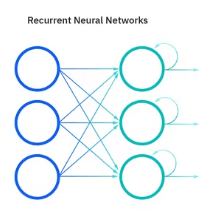

* **LSTM (Long Short-Term Memory)**: Uma evolução das RNNs que utiliza portões de memória para capturar dependências de longo prazo, sendo amplamente superior para prever a RUL por resolver o problema de desaparecimento do gradiente.
O diferencial desse método é devido a aplicação do conceito de **célula de memória** que funciona como uma "esteira transportadora" de informações ao longo do tempo.

Para Rajneesh (2025), o fluxo de dados do LSTM é regulado por três mecanismos de controle chamados **portões (gates)**, baseados na função de ativação sigmóide (que gera valores entre 0 e 1).

1. **Forget Gate**: Decide quais informações do estado anterior da célula devem ser descartadas.

2. **Input Gate**: Determina quais novos dados da entrada atual serão armazenados na célula.

3. **Output Gate**: Define qual parte do estado interno da célula será enviada como saída para o próximo passo temporal.

**Figura 4**

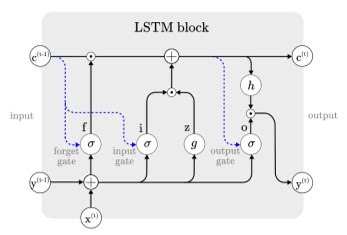


Esse modelo tem como principais vantagens a **memória de longo-prazo**, **fim da engenharia manual** e **robustez**, porém exige uma **complexidade maior de treinamento** e **alto custo computacional** para séries temporais mais longas e com centenas de variáveis, além de ser de **natureza "Caixa-Preta"**, oferecendo baixa interpretabilidade sobre quais sensores ou momentos foram decisivos para a previsão.


--------------------------------------------------------------------------------
## **Trabalhos Correlacionados**

Como principais *benchmarkings* de trabalhos acadêmicos que aplicaram o conceito de RUL para turbofans, temos:

**Remaining Useful Life Estimation of Turbofan Engines with Deep Learning Using Change-Point Detection Based Labeling and Feature Engineering (Ensarioğlu et al., 2023):**
Este projeto propõe uma abordagem focada no refinamento da rotulagem dos dados e na engenharia de recursos As principais técnicas utilizadas incluem **Detecção de Ponto de Mudança (Change-Point Detection)** para determinar o momento exato em que a degradação começa para cada motor individualmente, em vez de assumir um valor constante para toda a frota. Além disso, é utilizada a **Engenharia de Recursos Híbrida**, introduzindo um recurso artesanal baseado na diferença entre a medição atual e a primeira medição do sensor, capturando a tendência de degradação desde o início da operação.

**Predicting Remaining Useful Life of Turbofan Engines on CMAPSS and N-CMAPSS using Deep Recurrent Neural Networks (Tippareddy, 2024)**:
  Explora as técnicas de **LSTM Bidirecional (Bi-LSTM)**, a qual é identificada como a arquitetura de melhor desempenho para a maioria dos subconjuntos, pois processa dados em ambas as direções temporais para capturar relações complexas.
De forma complementar, também é utilizado a **Sliding Window**, para aplicar janelas de tamanho fixo para processar as séries temporais como entradas para os modelos de Deep Learning e também o **Pré-processamento Avançado** que utiliza Análise de Componentes Principais (PCA) para redução de dimensionalidade e análise de correlação para seleção de sensores críticos.




--------------------------------------------------------------------------------

# **Pipeline da Solução**

O *pipeline* da solução proposta nesse projeto com o CMAPSS será estruturado com base na metodologia CRISP-DM, que é um *framework* cíclico, amplamente utilizando em projetos de ciência de dados e mineração de dados, que garante que as soluções resolvam problemas reais de negócio, cobrindo, em seis fases, desde o entendimento da necessidade até a implantação do algoritmo.

**Figura 5**

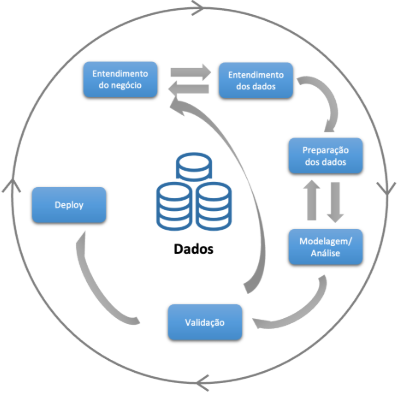

O projeto se baseará nos conceitos do artigo ***Predicting Remaining Useful Life of Turbofan Engines on CMAPSS and N-CMAPSS  
using Deep Recurrent Neural Networks (Samaikya Tippareddy, 2024
)*** tendo como diferencial a utilização da metodologia estruturada abaixo e simplificação do modelo utilizando o *dataset* CMAPSS ao invés do N-CMAPSS, o que garantirá uma solução mais simplificada e que reduza os custos computacionais.

## **1. Entendimento do Negócio**
O objetivo central é transformar a manutenção de motores aeronáuticos de reativa para preditiva, reduzindo custos operacionais e aumentando a segurança através da estimativa precisa de quantos ciclos de voo restam antes de uma falha funcional. O sucesso do projeto é definido pela minimização do erro de previsão, permitindo intervenções de manutenção otimizadas e evitando falhas catastróficas.

## **2. Entendimento dos Dados**

Nesta fase, utiliza-se o dataset CMAPSS da NASA, composto pelos quatro subconjuntos citados em tópicos anteriores (FD001 a FD004) que simulam a degradação de motores sob diferentes condições operacionais e modos de falha.

* **Análise Exploratória (EDA)**: Realiza-se a análise de correlação através de Mapas de Calor (Heatmaps) para identificar quais dos 21 sensores apresentam tendências de degradação significativas.

* **Identificação de Ruído**: Identificação dos sensores constantes ou que apresentam baixa variância.

## **3. Preparação dos Dados**

* **Limpeza e Seleção**: Remoção de sensores irrelevantes/constantes e manutenção apenas daqueles que demonstram correlação com a progressão da RUL.

* **Rotulagem Piecewise Linear**: Em vez de uma degradação linear simples, aplica-se o modelo Linear por Partes, fixando a RUL em um valor máximo (por exemplo, com subdivisão entre 125 ou 130 ciclos) durante a fase inicial de saúde, decrescendo linearmente apenas após o início da degradação.

* **Normalização**: Utiliza-se preferencialmente o *StandardScaler* para reescalar os dados de sensores para média zero e desvio padrão unitário, garantindo que sensores com magnitudes diferentes contribuam igualmente para o aprendizado.

* **Sliding Window**: Os dados são convertidos de pontos isolados para sequências temporais de tamanho fixo (janela de 30 ciclos), permitindo que o modelo capture dependências temporais e tendências de longo prazo.

## **4. Modelagem**

Nessa etapa, utilizaremos como base a arquitetura central proposta por Tippareddy para o CMAPSS, a qual fundamenta-se em Redes Neurais Recorrentes Profundas. Exploraremos as relações e possíveis simplificações do modelo.

* **Algoritmo Principal: LSTM Bidirecional (Bi-LSTM)**: Processa as janelas de dados em ambas as direções temporais, capturando relações intrincadas entre o histórico passado e os estados futuros de degradação.

* **Otimização**: Com base no artigo citado, a proposta de otimização é o ajuste de hiperparâmetros (como número de neurônios, taxa de aprendizado e tamanho do lote) utilizando técnicas como K-Fold Cross-Validation para garantir a generalização do modelo.

## **5. Validação**

A proposta é realizar a avaliação do modelo com base nas princípais métricas de performance de Aprendizado de Máquina e algoritmos de predição de RUL, como:

* **RMSE (Root Mean Squared Error)**: Métrica primária para quantificar a magnitude média do erro de previsão.

* **NASA Score**: Função de pontuação assimétrica que penaliza mais severamente as previsões tardias (subestimação da RUL) do que as antecipadas, refletindo o risco maior de falha inesperada na aviação.

## **6. Deploy**
O modelo final, no caso de utilização na vida real, pode ser exportado para ser integrado em um sistema de suporte à decisão de manutenção em companhias aéreas e fabricantes de aeronaves.

Nessa etapa, é essencial acompanhar o desempenho do modelo em operação real para detectar mudanças no comportamento de falha dos motores ao longo do tempo e retroalimentação do modelo com base em dados reais de vôo, o que exige estruturação de pipelines de processamento em lotes, exigindo alto custo computacional futuro.

# **EDA e Pré-processamento dos dados**

Nessa etapa será realizada a primeira análise exploratória dos dados e processamento do dataset CMAPSS da NASA, focando em um modelo de Bi-LSTM como demonstrado no referencial teórico.


**EDA (Análise Exploratória)**

Nessa etapa, o objetivo será focar nas características do dataset CMAPSS relacionadas às principais qualidades e limitações, o que será fundamental para aplicação do modelo no contexto correto. Para isso, deve-se sempre levar em conta as seguintes premissas:

1.  **Qualidade:** Os dados são multivariados e incluem ruído de sensor simulado para representar condições reais.

2.  **Limitações:** No CMAPSS original, o início da degradação não depende do histórico de operação passado, o que significa que o algoritmo só pode prever a evolução da falha, não o seu surgimento inicial.

3. **Recortes:** Adota-se o foco em sensores que demonstram tendências monotônicas (crescimento ou decréscimo constante), descartando sensores que permanecem constantes e que poderiam distrair o modelo.


**Importação de Bibliotecas**

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

**Criação do dataset**

In [72]:
# Para iniciar a análise exploratória (EDA) e o algoritmo LSTM, será utilizado o sub-dataset FD001 (train_FD001.txt)
# Motivo: É mais simples pois possui apenas uma condição operacional (nível do mar) e um modo de falha (degradação do HPC)

# Definição das colunas padrão do manual CMAPSS
index_names = ['unit', 'cycle']
setting_names = ['setting1', 'setting2', 'setting3']
sensor_names = [f's{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

df = pd.read_csv('/content/train_FD001.txt', sep=r'\s+', header=None, names=col_names)

**Análise Correlacional**

In [95]:
# A análise de correlação será usada para identificar colinearidade entre os sensores e entender a força da relação entre as variáveis
# Nesse caso, será utilizado Mapas de Calor (Heatmaps) para visualizar essas relações e decidir sobre possíveis reduções de dimensionalidade

def correlational_analysis(df):
    # Cálculo da matriz de correlação de Pearson
    plt.figure(figsize=(12, 10))
    corr_matrix = df.corr()

    # Visualização via Heatmap
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Matriz de Correlação (Gráfico 1)")
    plt.show()

    return corr_matrix

**Mapa de Calor**

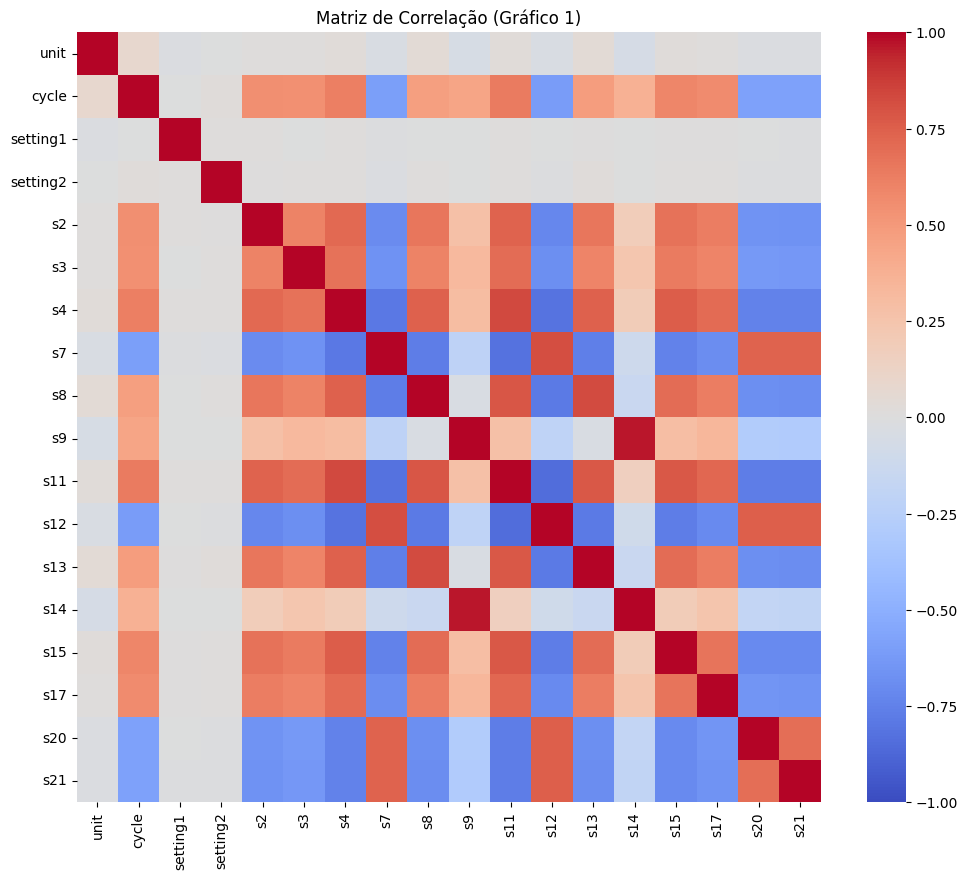

,unit,cycle,setting1,setting2,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
unit,1.000000,0.078753,-0.017895,-0.006197,0.014133,0.012621,0.026116,-0.032073,0.039929,-0.052053,0.024707,-0.031882,0.044230,-0.059473,0.022486,0.013513,-0.020589,-0.016465
cycle,0.078753,1.000000,-0.004527,0.016132,0.549898,0.543947,0.624577,-0.595914,0.475977,0.443999,0.634385,-0.611354,0.477523,0.370324,0.588676,0.566995,-0.583597,-0.585923
setting1,-0.017895,-0.004527,1.000000,0.011660,0.009030,-0.005651,0.009544,-0.009437,-0.000427,-0.004279,0.011658,-0.001491,0.002318,-0.004469,0.007652,0.002599,-0.005713,-0.014559
setting2,-0.006197,0.016132,0.011660,1.000000,0.007266,0.009068,0.014673,-0.016678,0.013285,-0.005425,0.011690,-0.010923,0.018156,-0.006310,0.014156,0.012280,-0.010554,-0.007846
s2,0.014133,0.549898,0.009030,0.007266,1.000000,0.602610,0.714949,-0.702136,0.662325,0.273764,0.740020,-0.724578,0.661792,0.179752,0.675975,0.629886,-0.661841,-0.668050
s3,0.012621,0.543947,-0.005651,0.009068,0.602610,1.000000,0.678413,-0.664595,0.602481,0.322964,0.695900,-0.680307,0.600963,0.237137,0.639921,0.600017,-0.625941,-0.633901
s4,0.026116,0.624577,0.009544,0.014673,0.714949,0.678413,1.000000,-0.793130,0.746852,0.297429,0.830136,-0.815591,0.745158,0.190748,0.758459,0.703499,-0.748067,-0.745193
s7,-0.032073,-0.595914,-0.009437,-0.016678,-0.702136,-0.664595,-0.793130,1.000000,-0.767132,-0.217835,-0.822805,0.812713,-0.764611,-0.110053,-0.747051,-0.692893,0.736163,0.737447
s8,0.039929,0.475977,-0.000427,0.013285,0.662325,0.602481,0.746852,-0.767132,1.000000,-0.032091,0.782213,-0.786540,0.826084,-0.144787,0.700949,0.627785,-0.687030,-0.688840
s9,-0.052053,0.443999,-0.004279,-0.005425,0.273764,0.322964,0.297429,-0.217835,-0.032091,1.000000,0.274591,-0.210238,-0.034763,0.963157,0.293753,0.337110,-0.285280,-0.292795


In [96]:
# Identificação de colunas constantes (std=0) e irrelevantes
# Sensores como s1, s5, s6, s10, s16, s18, s19 e 'setting3' são descartados
drop_cols = ['setting3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']
df_cleaned = df.drop(columns=drop_cols)

correlational_analysis(df_cleaned)

Nesse mapa de calor gerado (Gráfico 1), podemos visualizar as correlações entre diferentes variáveis no conjunto de dados.

A correlação varia de -1 a 0 e até +1. O valor -1 indica uma correlação negativa ilustrada pela cor azul-escura, 0 indica ausência de correlação com a cor cinza e +1 indica uma correlação positiva com a cor vermelha. A correlação entre quaisquer duas variáveis flutua entre esses valores.

Por exemplo, a correlação entre as variáveis 'S9' e 'S14' apresenta uma correlação positiva alta de +1. Padrões de correlação semelhantes foram observados em todos os conjuntos de dados do CMAPSS.

**Análise Bivariada**

In [106]:
def bivariate_deviation_analysis_all_sensors(df, unit_id=52):

    # 1. Filtragem dos dados da unidade específica (foi escolhida a unidade 52 para essa análise)
    unit_data = df[df['unit'] == unit_id]

    # 2. Identificação dos sensores (s1 a s21)
    # Sensores s1, s5, s6, s10, s16, s18 e s19 são constantes e foram removidos
    constant_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
    sensor_cols = [f's{i}' for i in range(1, 22) if f's{i}' not in constant_sensors]

    # 3. Configuração do Grid de Gráficos (ex: 5 linhas x 3 colunas)
    num_sensors = len(sensor_cols)
    cols = 3
    rows = (num_sensors // cols) + (1 if num_sensors % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = axes.flatten() # Transforma a matriz de eixos em uma lista linear

    # 4. Iteração e Plotagem de cada sensor
    for i, sensor in enumerate(sensor_cols):
        axes[i].plot(unit_data['cycle'], unit_data[sensor], color='tab:blue', alpha=0.8)
        axes[i].set_title(f"Evolução Temporal: {sensor}")
        axes[i].set_xlabel("Ciclos")
        axes[i].set_ylabel("Leitura")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    # 5. Remoção de subplots vazios (caso o número de sensores não seja múltiplo de 3)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Análise de Magnitude dos Sensores - Unidade {unit_id} (Gráfico 2)", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

    # Retorna o dataframe amostrado (cada 20º registro) como no original
    return df.iloc[::20, :].copy()


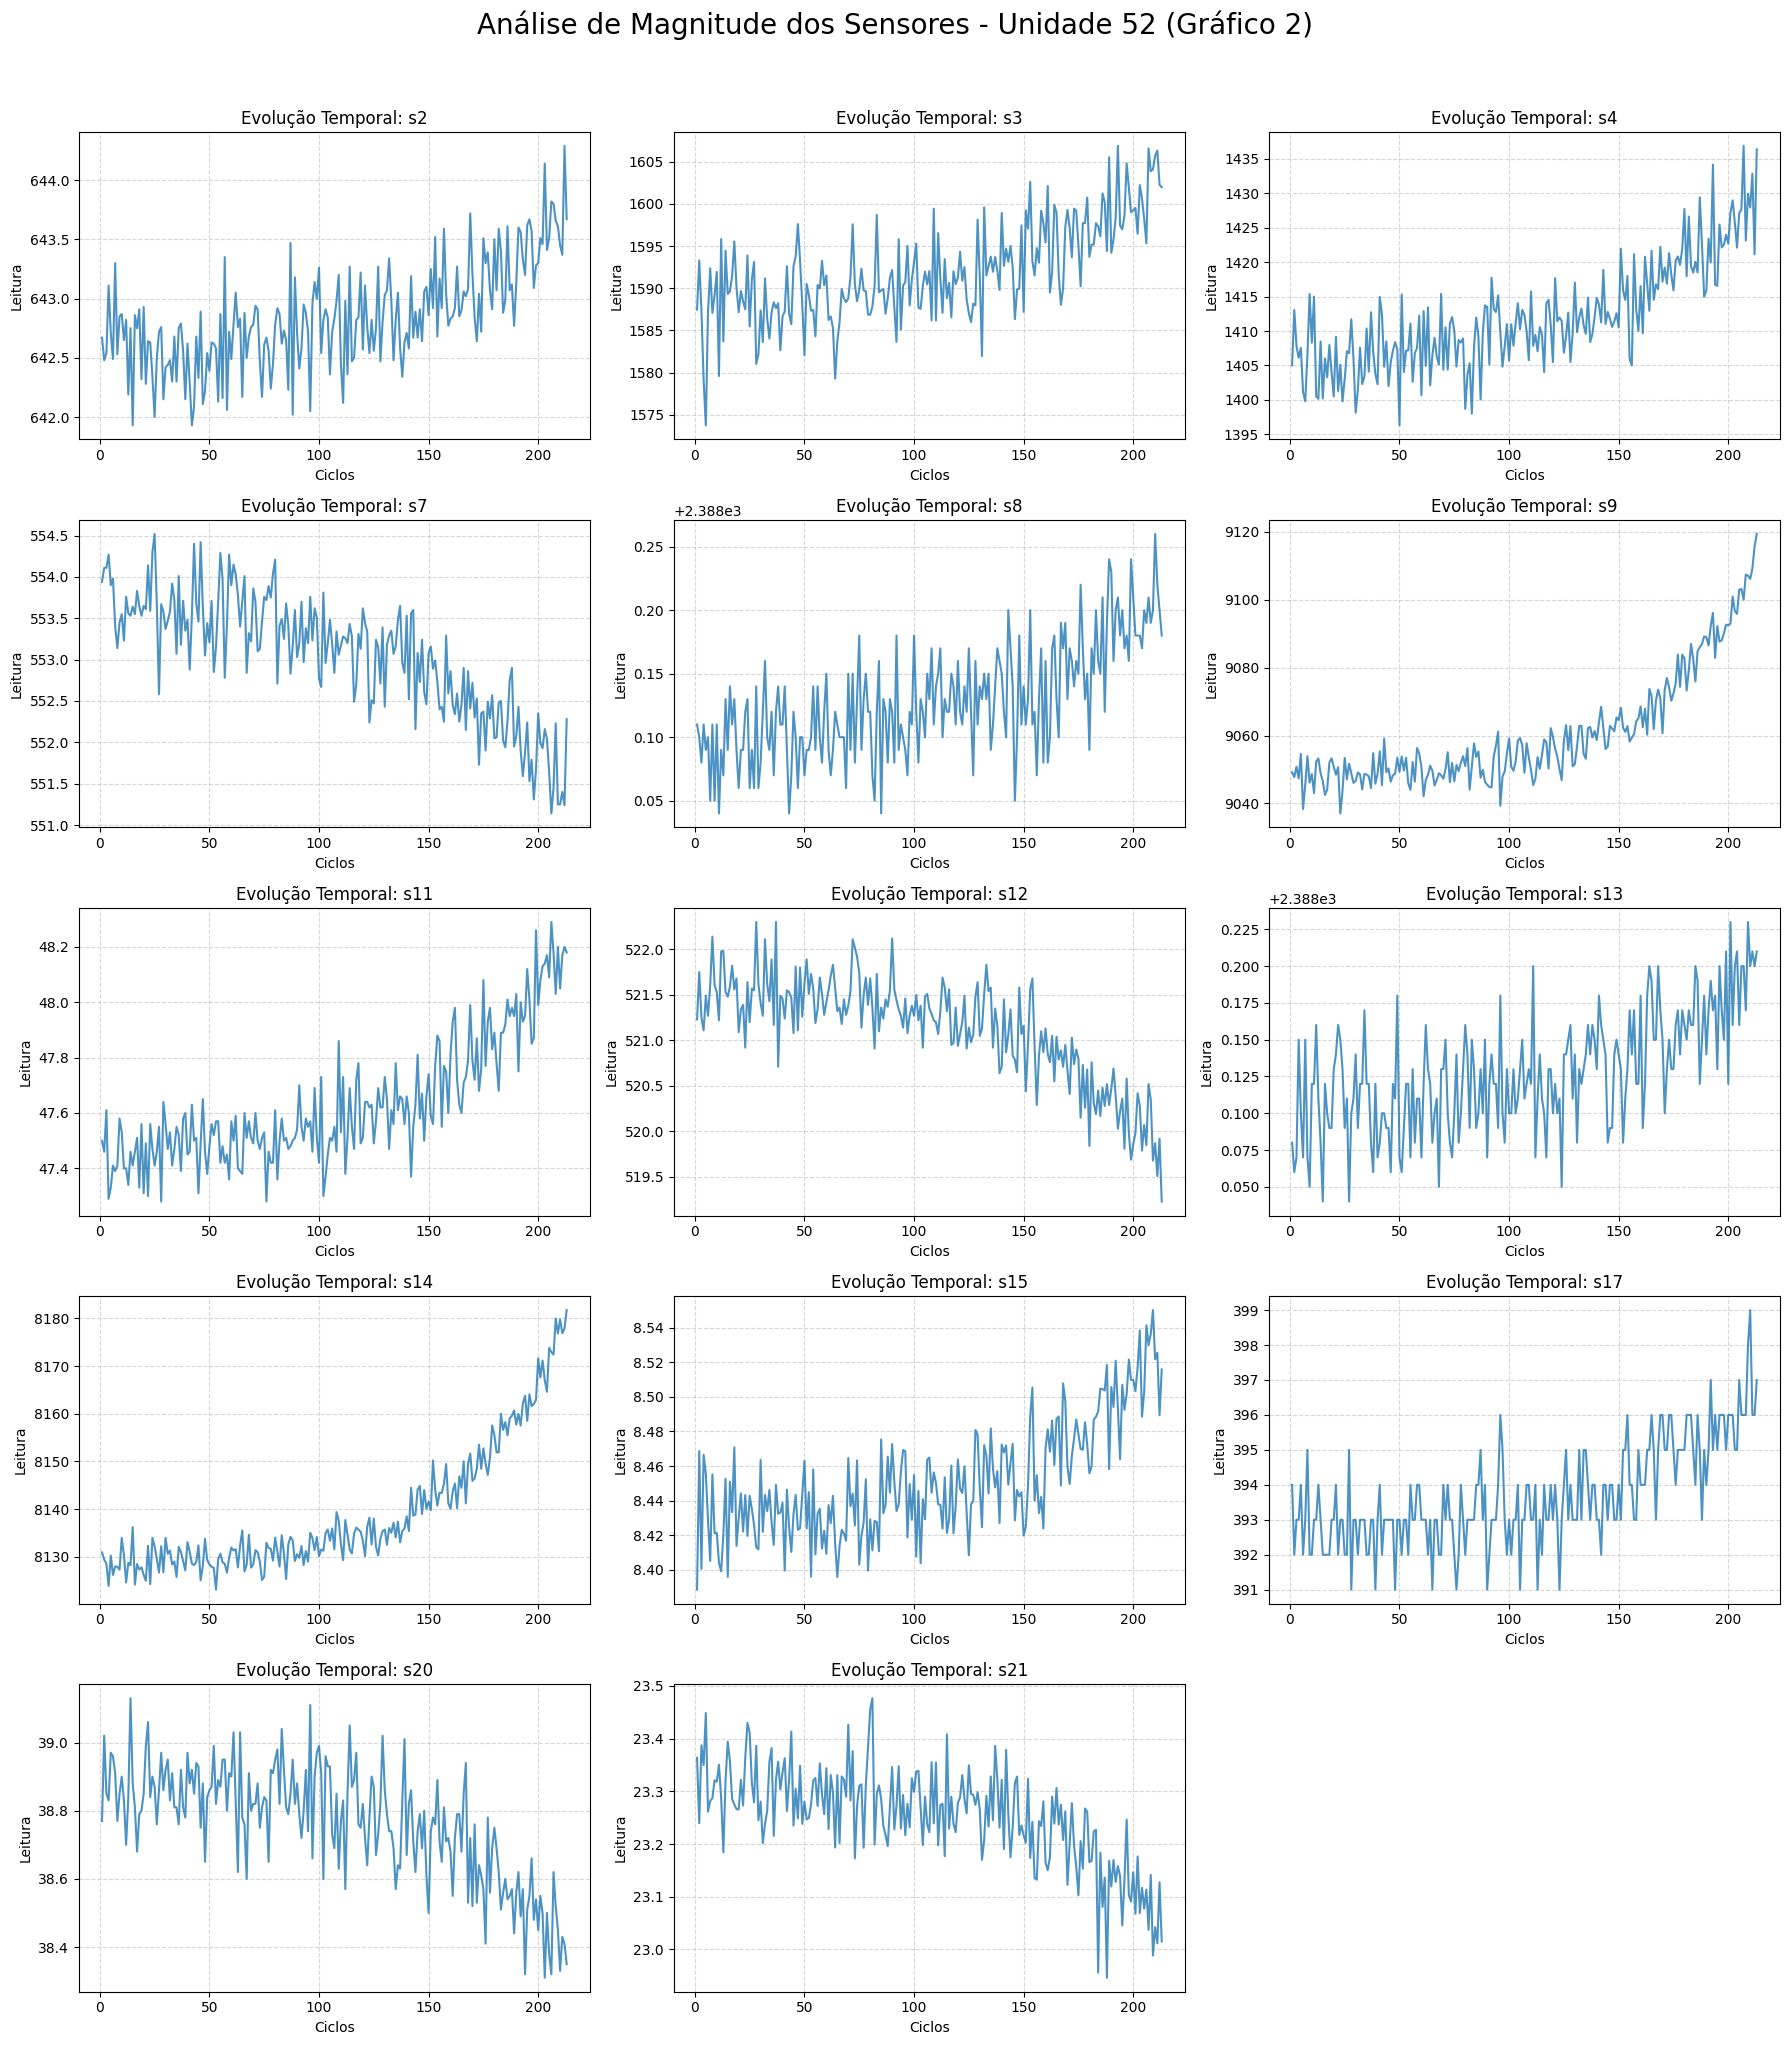

,unit,cycle,setting1,setting2,s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
20,1,21,-0.0012,0.0001,642.37,1586.07,1398.13,554.08,2388.11,9048.15,47.15,522.42,2388.08,8134.02,8.4049,392,39.09,23.3101
40,1,41,0.0033,0.0004,642.40,1591.31,1403.21,553.72,2388.06,9048.99,47.09,522.07,2388.03,8138.08,8.4370,392,39.13,23.4444
60,1,61,0.0004,0.0005,642.10,1583.55,1405.52,554.09,2388.11,9050.58,47.31,522.34,2388.09,8131.66,8.4264,391,38.89,23.3638
80,1,81,-0.0018,-0.0004,642.73,1584.82,1402.04,553.88,2388.10,9045.31,47.43,521.66,2388.05,8128.87,8.4247,392,38.77,23.3730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20540,100,110,0.0006,-0.0004,643.37,1587.51,1406.25,553.23,2388.14,9062.22,47.46,520.96,2388.14,8136.26,8.4458,394,38.52,23.2913
20560,100,130,-0.0022,0.0001,642.51,1590.18,1405.59,553.51,2388.07,9058.88,47.49,521.14,2388.08,8137.59,8.4389,393,38.73,23.2763
20580,100,150,-0.0001,-0.0003,642.43,1601.62,1411.04,552.98,2388.09,9066.81,47.76,521.05,2388.13,8140.00,8.4376,395,38.62,23.2022
20600,100,170,-0.0034,0.0003,642.71,1593.42,1427.68,552.22,2388.15,9071.43,48.01,520.06,2388.19,8147.15,8.5044,394,38.63,23.1563


In [107]:
bivariate_deviation_analysis_all_sensors(df_cleaned, unit_id=52)

No conjunto de gráficos acima (Gráfico 2), é possível verificar, na Unidade 52, uma tendência clara de mudança do valor lido por cada um dos sensores não constantes conforme aumento do tempo de uso do motor.

Com isso, é formulada a hipótese de que a variância dos dados lidos x esperados aumenta conforme o motor se aproxima da falha. Conforme os motores degradam, é comum observar o fenômeno da heterocedasticidade, onde a variância do erro ou do sinal aumenta à medida que o tempo progride.

O objetivo da análise abaixo é observar que, à medida que o motor se aproxima do fim da vida útil (RUL próximo de zero), essa diferença não só aumenta em magnitude (como demonstrado no gráfico anterior), mas também em instabilidade/variância.


**Análise Temporal de Variância x Ciclos**

In [104]:
def analyze_all_sensors_variance(file_path, window_size=20):

    # 1. Carregamento com nomes de colunas padrão
    index_names = ['unit', 'cycle']
    setting_names = ['os1', 'os2', 'os3']
    sensor_names = [f's{i}' for i in range(1, 22)]
    col_names = index_names + setting_names + sensor_names
    df = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)

    # 2. Identificação e remoção de sensores constantes
    # Sensores sem variação não possuem aumento de variância
    informative_sensors = [s for s in sensor_names if df[s].std() > 1e-5]
    print(f"Sensores constantes removidos: {set(sensor_names) - set(informative_sensors)}")

    # 3. Cálculo da Variância Dinâmica (Rolling Variance)
    # Calculamos o desvio padrão em uma janela móvel para cada unidade
    rolling_variance_list = []
    for unit in df['unit'].unique():
        unit_data = df[df['unit'] == unit].copy()
        # Calculamos o desvio padrão rolante para capturar a dispersão local de cada janela
        rolling_std = unit_data[informative_sensors].rolling(window=window_size).std()
        rolling_std['cycle'] = unit_data['cycle']
        rolling_variance_list.append(rolling_std)

    df_rolling = pd.concat(rolling_variance_list).dropna()

    # 4. Visualização de todos os sensores informativos
    num_sensors = len(informative_sensors)
    cols = 3
    rows = (num_sensors // cols) + (1 if num_sensors % cols != 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, sensor in enumerate(informative_sensors):
        # Agrupamos por ciclo para ver a tendência média da variância na frota
        mean_variance_trend = df_rolling.groupby('cycle')[sensor].mean()

        sns.lineplot(x=mean_variance_trend.index, y=mean_variance_trend.values, ax=axes[i])
        axes[i].set_title(f"Variância DinÂmica: {sensor}")
        axes[i].set_xlabel("Ciclos")
        axes[i].set_ylabel("Std Dev Médio")

    # Remove subplots vazios
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(f"Análise de Heterocedasticidade - Janela de {window_size} Ciclos (Gráfico 3)", fontsize=20, y=1.02)
    plt.show()

Sensores constantes removidos: {'s5', 's1', 's10', 's18', 's19', 's16'}


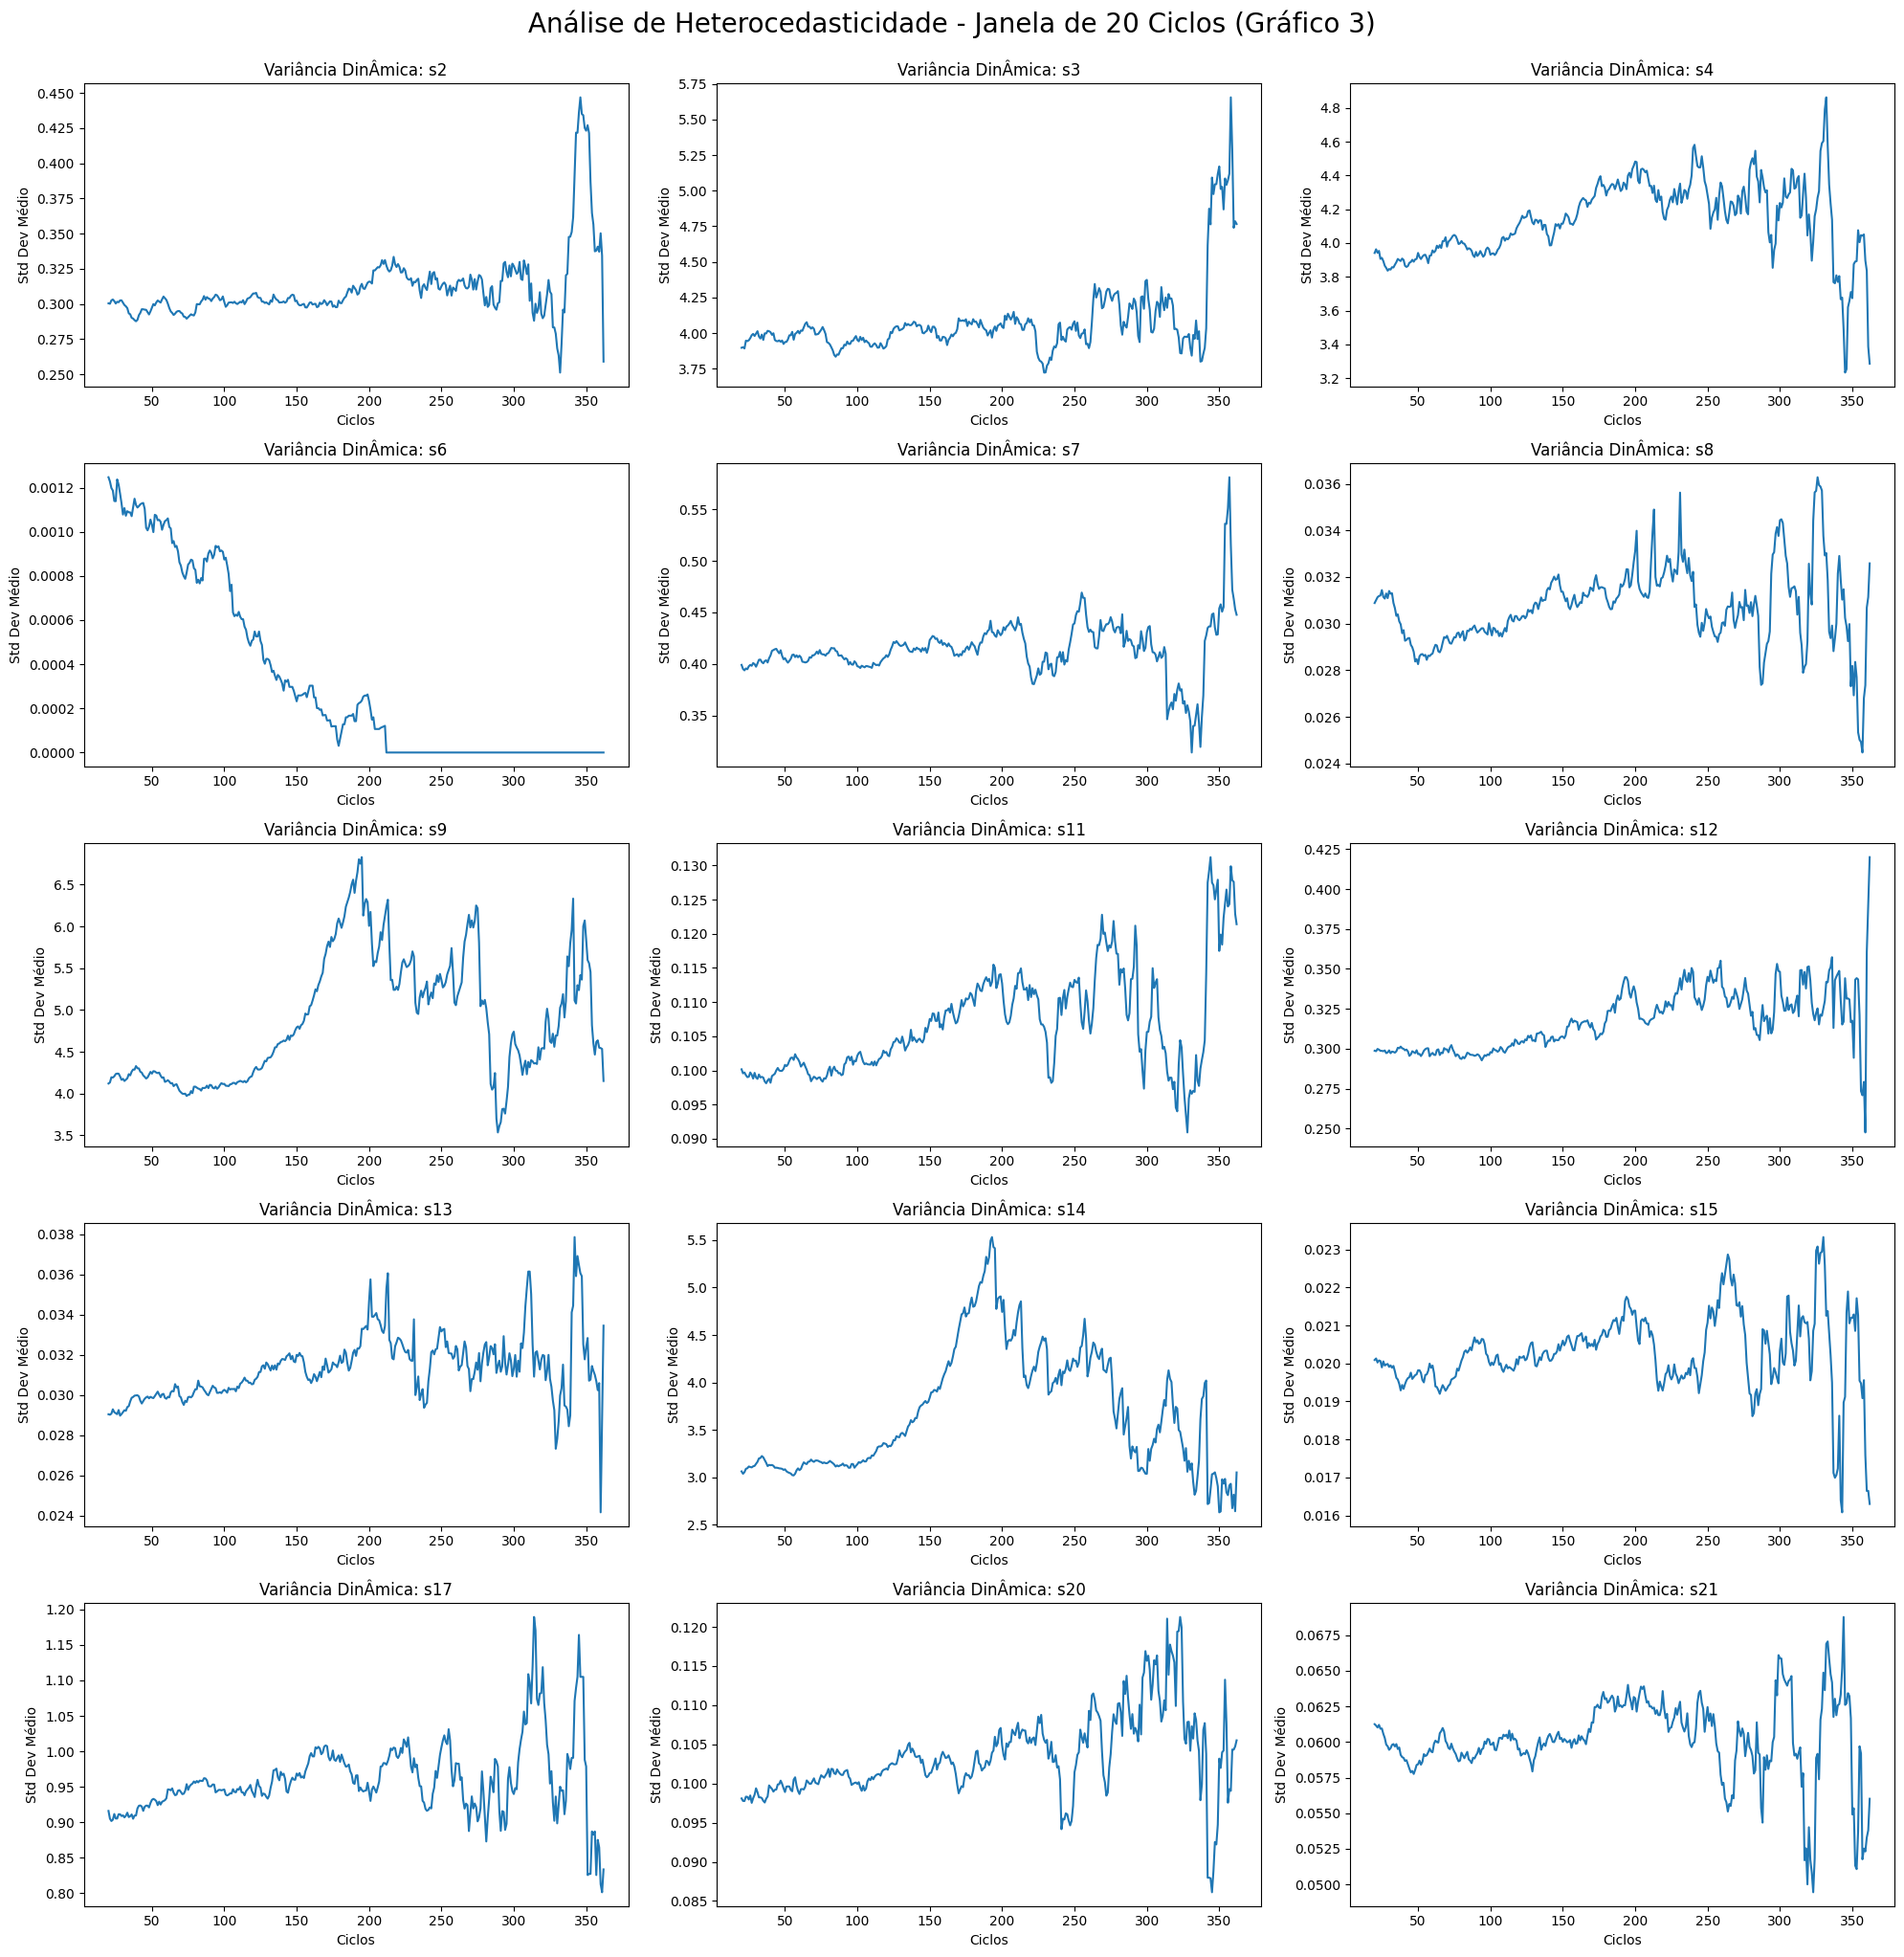

In [105]:
analyze_all_sensors_variance('train_FD001.txt')

Conforme discutido os motores exibem variabilidades significativamente maiores nas trajetórias dos sensores conforme aumento do número de ciclos.

No gráfico de Heterocedastida (Gráfico 3), é possível visualizar que, para sensores críticos como s11 e s3, a linha de desvio padrão médio tende a subir conforme o número de ciclos aumenta, indicando que o ruído e a instabilidade física crescem perto da falha.

Um dos pontos-chave na análise é que, conforme mencionado no referencial teórico, o uso de uma janela (ex: 20 ciclos) é fundamental para suavizar picos aleatórios e focar na tendência de dispersão.

Se a variância aumentar de forma consistente, isso valida o uso de algoritmos que capturam dependências temporais, como a LSTM, que pode aprender a distinguir o ruído saudável da instabilidade de pré-falha.

Conforme estudo de Tippareddy (2024), ao visualizar todos os sensores, é possível observar que a variância do sinal tende a aumentar em alguns sensores à medida que o motor se aproxima da falha (ciclos mais altos), um comportamento típico de sistemas físicos em degradação acelerada.


## Tarefas de Preparação dos dados:

Utilizando como base o trabalho de Tippareddy (2024) e nas boas práticas de modelos LSTM, o pipeline de preparação envolve quatro etapas críticas para algoritmos recorrentes:

1. **Limpeza:** Remoção de sensores com variância zero (ex: sensores 1, 5, 6, 10, 16, 18 e 19 no subconjunto FD001).

2. **Rotulagem Piecewise Linear:** Aplicação de um teto (geralmente 125 ciclos) para a RUL inicial. Isso evita que o modelo tente prever falhas em motores perfeitamente saudáveis, focando o aprendizado na fase de degradação real.

3. **Normalização:** Utilização do StandardScaler ou MinMaxScaler para garantir que todos os sensores contribuam igualmente, evitando que sensores com grandes magnitudes dominem os pesos da rede.

4. **Janelamento (Sliding Window):** Transformação dos dados 2D em tensores 3D (amostras, 30 ciclos, features), permitindo que a LSTM capture a dependência temporal e tendências de longo prazo.


In [100]:
def prepare_data(df, max_rul=125, window_size=30):

    # Rotulagem Piecewise Linear
    # Calcula RUL real e aplica o limite (capping)
    rul_grouped = df.groupby('unit')['cycle'].max()
    df = df.merge(rul_grouped.to_frame(name='max_cycle'), left_on='unit', right_index=True)
    df['RUL'] = df['max_cycle'] - df['cycle']
    df['RUL'] = df['RUL'].clip(upper=max_rul)
    df.drop('max_cycle', axis=1, inplace=True)

    # Limpeza e Seleção de Features
    # Sensores irrelevantes ou constantes identificados na EDA
    drop_cols = ['setting3', 's1', 's5', 's6', 's10', 's16', 's18', 's19']
    df.drop(columns=drop_cols, inplace=True)

    #  Normalização (StandardScaler)
    feature_cols = [c for c in df.columns if c not in ['unit', 'cycle', 'RUL']]
    scaler = StandardScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    # D. Janelamento Deslizante (Sliding Window)
    # Converte para formato (amostras, timesteps, features)
    def gen_sequence(id_df, seq_length, seq_cols):
        data_matrix = id_df[seq_cols].values
        num_elements = data_matrix.shape[0] # Corrected: Get the number of rows
        for start, stop in zip(range(0, num_elements-seq_length+1), range(seq_length, num_elements+1)):
            yield data_matrix[start:stop, :]

    def gen_labels(id_df, seq_length, label_col):
        data_matrix = id_df[label_col].values
        num_elements = data_matrix.shape[0] # Corrected: Get the number of rows
        # O label da sequência é a RUL do último ciclo da janela
        return data_matrix[seq_length-1:]

    # Gerando as sequências por unidade de motor
    sequence_list = []
    label_list = []

    for unit in df['unit'].unique():
        unit_df = df[df['unit'] == unit]
        if len(unit_df) >= window_size:
            sequence_list.append(list(gen_sequence(unit_df, window_size, feature_cols)))
            label_list.append(gen_labels(unit_df, window_size, ['RUL']))

    X = np.concatenate(sequence_list).astype(np.float32)
    y = np.concatenate(label_list).astype(np.float32)

    print(f"\nDados preparados para LSTM:")
    print(f"Formato de X (amostras, timesteps, features): {X.shape}")
    print(f"Formato de y: {y.shape}")

    return X, y

In [101]:
X_train, y_train = prepare_data(df.copy(), max_rul=125, window_size=30)


Dados preparados para LSTM:
Formato de X (amostras, timesteps, features): (17731, 30, 16)
Formato de y: (17731, 1)


# **Modelo base**

O código baseline abaixo implementa uma rede neural profunda projetada para capturar dependências temporais em séries de dados de sensores, sendo, de início, utilizado apenas o sub-dataset FD001 para operação simplificada a nível do mar, sendo esperado, por conta disso, resultados piores do que a literatura demonstra.

O restante do dataset será utilizado nas próximas etapas.

São utilizados os seguintes componentes:

1.  **Arquitetura Stacked LSTM:** O empilhamento de camadas permite que a rede aprenda representações hierárquicas, onde a primeira camada (100 unidades) captura padrões temporais brutos e a segunda (50 unidades) extrai características mais abstratas desses padrões.

2.   **Processamento Sequencial:** O modelo exige que os dados de entrada estejam no formato de tensor 3D (amostras, timesteps, features), permitindo que a rede "lembre" informações de muitos ciclos anteriores através de seus portões internos (gates).

3. **Regularização com Dropout:** A inserção de camadas de Dropout (0.2) entre as LSTMs é crucial para evitar o overfitting (sobreajuste), forçando a rede a aprender padrões mais robustos em vez de apenas memorizar o ruído dos dados de treinamento.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        46,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,051 (300.98 KB)

 Trainable params: 77,051 (300.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 5614.9341 - val_loss: 4810.8916
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 3384.4895 - val_loss: 2953.7217
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 2041.8557 - val_loss: 1809.7635
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 1229.5071 - val_loss: 1092.0826
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 747.2322 - val_loss: 668.5548
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 478.1143 - val_loss: 447.6091
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - loss: 322.0153 - val_loss: 306.9633
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 238.3720 - val_loss: 294.0373
Epoch 9/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 188.6761 - val_loss: 231.2001
Epoch 10/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 158.5460 - val_loss: 229.5537
Epoch 11/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 138.6861

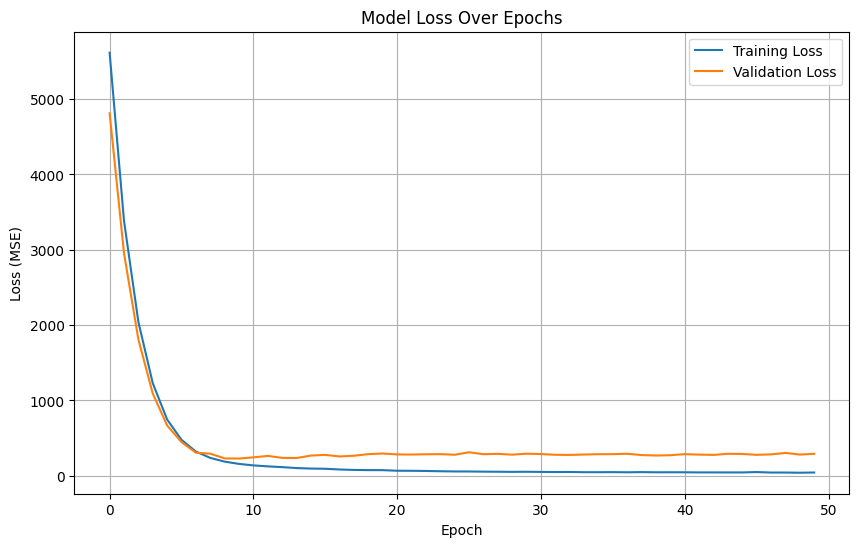

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define o modelo LSTM
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(units=100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1) # Camada de saída para regressão RUL
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

# O input_shape deve ser (window_size, num_features)
num_features = X_train.shape[2]
window_size = X_train.shape[1]
input_shape = (window_size, num_features)

model = build_lstm_model(input_shape)
model.summary()

# Treinamento do modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # 20% dos dados de treino serão usados para validação
    verbose=1
)

# Plotar o histórico de treinamento (loss)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

**Geração de Predições e Métricas de Precisão (RMSE e MAE)**

In [91]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Gerar predições para o conjunto de teste (20% separados do sub-dataset de treino FD001)
y_pred = model.predict(X_test)

# 2. Calcular RMSE e MAE
# O RMSE penaliza erros grandes, crucial para segurança
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Desempenho nos 20% de teste:")
print(f"RMSE: {rmse:.2f} ciclos")
print(f"MAE: {mae:.2f} ciclos")

319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Desempenho nos 20% de teste:
RMSE: 41.92 ciclos
MAE: 32.74 ciclos


É possível verificar que o RMSE ficou próximo aos 42 ciclos e MAE próximo aos 33 ciclos.

Os resultados obtidos estão consideravelmente acima do benchmarking com o artigo de Tippareddy (o que é esperado, pois o objetivo inicial é apenas realizar um teste de base para a próxima etapa), que atingiu um RMSE entre 13 e 18 ciclos.

O erro médio absoluto de ~33 ciclos demonstra que, em termos práticos, em uma operação de 1 ciclo por voo o modelo está errando por um mês de operação. Trabalhos como o de Ahmed (2025) reportam o MAE em torno de 11.67 ciclos, o que deve ser buscado na próxima etapa do projeto.

**Cálculo do NASA Score (Métrica Assimétrica)**

Aplicação da Função de Pontuação da NADA (PHM08) que penaliza previsões tardias (atraso na manutenção) de forma exponencialmente mais severa do que previsões antecipadas.

In [92]:
def compute_nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    score = 0
    for d in diff:
        if d < 0: # Predição antecipada (mais segura)
            score += np.exp(-d / 13) - 1
        else: # Predição tardia (risco de falha)
            score += np.exp(d / 10) - 1
    return score

s_score = compute_nasa_score(y_test.flatten(), y_pred.flatten())
print(f"NASA Score: {s_score:.2f}")

NASA Score: 19080766.00


O valor obtido no modelo baseline para o NASA Score é o mais crítico. O valor obtido de 19 milhões sugere que o modelo prevê consistentemente que os motores terão uma vida útil muito maior do que a realidade (como é possível verificar no comportamento da previsão do tópico abaixo).

A partir disso, surge a necessidade de realizar o treinamento do modelo de forma bidirecional e com os outros sub-datasets do CMAPSS, pois esse número, para a aviação, é considerado um risco de falha catastrófica imprevisível.

**Comportamento da Previsão**

Foi utilizado um gráfico de tendência (RUL x Tempo) para mostrar se a predição (linha vermelha) acompanha a variação real (linha azul) conforme o motor se desgasta.

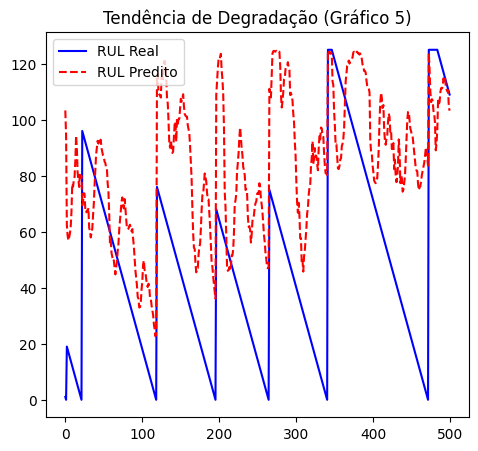

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de comparação RUL Real vs Predito
plt.subplot(1, 2, 1)
plt.plot(y_test[:500], label='RUL Real', color='blue') # Amostra dos primeiros 500 pontos
plt.plot(y_pred[:500], label='RUL Predito', color='red', linestyle='--')
plt.title('Tendência de Degradação (Gráfico 5)')
plt.legend()

Na análise da amostra acima (Gráfico 5) para a tendência de degradação, é possível verificar que o baseline mostrou uma vida útil prevista pelo modelo maior do que o RUL real.

Para melhorar este modelo inicial no futuro, serão explorados os casos dos sub-datasets adicionais para outros regimes de operação e utilização dos dados de teste fornecidos pela NASA ao invés de criar uma partição dos dados de treinamento.

Além disso, conforme literatura, deve-se realizar a transição para LSTMs Bidirecionais (que processam a sequência nos dois sentidos) para aumentar a acurácia do modelo.

# **Cronograma**

As principais atividades do projeto seguirão o cronograma abaixo em formato Gantt, o que garante melhor controle de prazos, subtarefas e dependências conforme complexidade e crescimento do projeto.


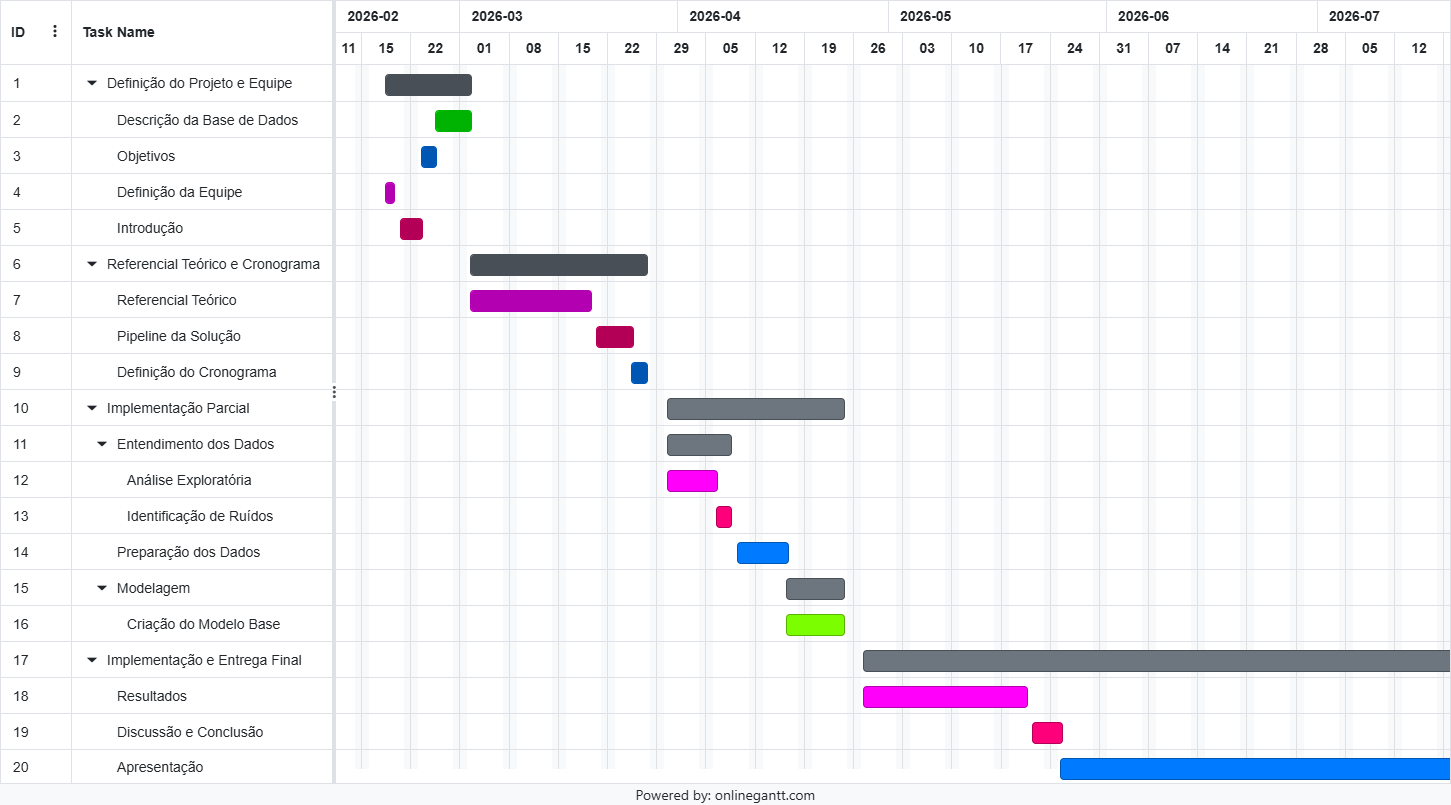



# **Referências**

CMAPSS Jet Engine Simulated Data. NASA Open Data Portal. Disponível em: https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data. Acesso em: 1 mar. 2026.

O que é uma rede neural recorrente?. Disponível em: https://www.ibm.com/br-pt/think/topics/recurrent-neural-networks. Acesso em: 27 mar. 2026.

SAXENA, A.; GOEBEL, K.; SIMON, D.; EKLUND, N. Damage propagation modeling for aircraft engine run-to-failure simulation. In: INTERNATIONAL CONFERENCE ON PROGNOSTICS AND HEALTH MANAGEMENT (PHM), 1., 2008, Denver, CO, USA. Proceedings [...]. Denver: IEEE, 2008. p. 1-9.

SHARMA, K. Uncertainty-Aware Deep Learning Framework for Remaining Useful Life Prediction in Turbofan Engines with Learned Aleatoric Uncertainty. [S. l.]: arXiv, 2025. (Preprint). DOI: 10.48550/arXiv.2511.19124. Disponível em: https://arxiv.org/abs/2511.19124.

TIPPAREDDY, S. Predicting Remaining Useful Life of Turbofan Engines on CMAPSS and N-CMAPSS using Deep Recurrent Neural Networks. 2024. 82 f. Master's Projects (Master of Science in Computer Science) – Computer Science Department, San José State University, San Jose, 2024.

ENSARIOĞLU, K.; İNKAYA, T.; EMEL, E. Remaining Useful Life Estimation of Turbofan Engines with Deep Learning Using Change-Point Detection Based Labeling and Feature Engineering. Applied Sciences, [S. l.], v. 13, n. 21, p. 11893, out. 2023

AHMED, Adam. Hybrid and deep learning architectures for predictive maintenance: Evaluating LSTM, and attention-based LSTM-XGBoost on turbofan engine RUL. MATEC Web of Conferences, v. 413, art. 07008, p. 1-8, out. 2025. DOI: https://doi.org/10.1051/matecconf/202541307008.

In [ ]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
